In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

In [6]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (6,4)

In [36]:
data_path = "/Users/kerel/Desktop/project_1_breast_cancer/data:/breast_cancer.csv"
df = pd.read_csv(data_path, header=None)
df = df.iloc[:, :-1]
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
1,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
2,842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902
3,84300903,M,19.69,21.25,130,1203,0.1096,0.1599,0.1974,0.1279,...,23.57,25.53,152.5,1709,0.1444,0.4245,0.4504,0.243,0.3613,0.08758
4,84348301,M,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,...,14.91,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.173


In [37]:
column_names = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df.columns = column_names
df.head()

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
1,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
2,842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902
3,84300903,M,19.69,21.25,130,1203,0.1096,0.1599,0.1974,0.1279,...,23.57,25.53,152.5,1709,0.1444,0.4245,0.4504,0.243,0.3613,0.08758
4,84348301,M,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,...,14.91,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.173


In [42]:
df = df.drop(index=0).reset_index(drop=True)
df.head()

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902
2,84300903,M,19.69,21.25,130,1203,0.1096,0.1599,0.1974,0.1279,...,23.57,25.53,152.5,1709,0.1444,0.4245,0.4504,0.243,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,...,14.91,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.173
4,84358402,M,20.29,14.34,135.1,1297,0.1003,0.1328,0.198,0.1043,...,22.54,16.67,152.2,1575,0.1374,0.205,0.4,0.1625,0.2364,0.07678


In [43]:
df.isnull().sum()

ID                         0
Diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [44]:
df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})
df["Diagnosis"].value_counts()

Diagnosis
0    357
1    212
Name: count, dtype: int64

In [45]:
df["Diagnosis"].unique()

array([1, 0])

In [46]:
df = df.drop(columns=["ID"])
df.shape

(569, 31)

In [47]:
data_dict = pd.DataFrame({
    "Variable": df.columns,
    "Type": ["Outcome"] + ["Numeric"] * (df.shape[1] - 1),
    "Missing (%)": df.isnull().mean() * 100
})

data_dict

,Variable,Type,Missing (%)
Diagnosis,Diagnosis,Outcome,0.0
radius_mean,radius_mean,Numeric,0.0
texture_mean,texture_mean,Numeric,0.0
perimeter_mean,perimeter_mean,Numeric,0.0
area_mean,area_mean,Numeric,0.0
smoothness_mean,smoothness_mean,Numeric,0.0
compactness_mean,compactness_mean,Numeric,0.0
concavity_mean,concavity_mean,Numeric,0.0
concave_points_mean,concave_points_mean,Numeric,0.0
symmetry_mean,symmetry_mean,Numeric,0.0


In [48]:
data_dict.to_csv("/Users/kerel/Desktop/project_1_breast_cancer/report:/data_dictionary.csv", index=False)

In [49]:
df.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
Diagnosis,569.0,0.372583,0.483918,0.0,0.0,0.0,1.0,1.0


In [50]:
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

In [51]:
X.shape, y.shape

((569, 30), (569,))

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [57]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.isnull().sum().sum()
df.dtypes.head(10)

Diagnosis                int64
radius_mean            float64
texture_mean           float64
perimeter_mean         float64
area_mean              float64
smoothness_mean        float64
compactness_mean       float64
concavity_mean         float64
concave_points_mean    float64
symmetry_mean          float64
dtype: object

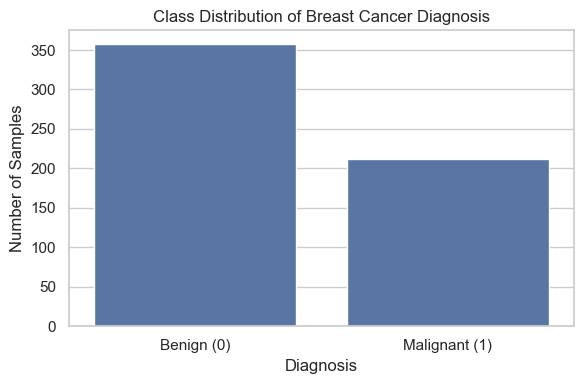

In [54]:
plt.figure()
sns.countplot(x="Diagnosis", data=df)
plt.xticks([0,1], ["Benign (0)", "Malignant (1)"])
plt.title("Class Distribution of Breast Cancer Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig("/Users/kerel/Desktop/project_1_breast_cancer/figures:/fig1_class_balance.png", dpi=300)
plt.show()

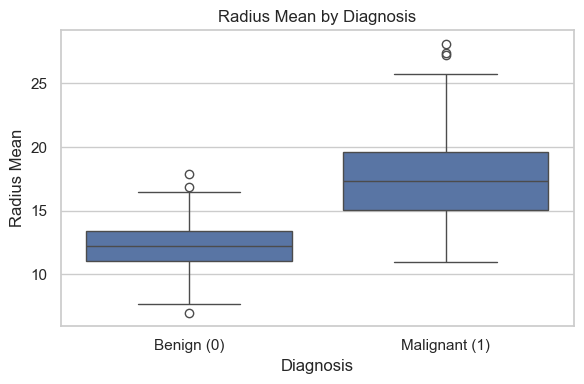

In [58]:
plt.figure()
sns.boxplot(data=df, x="Diagnosis", y="radius_mean")
plt.xticks([0,1], ["Benign (0)", "Malignant (1)"])
plt.title("Radius Mean by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Radius Mean")
plt.tight_layout()
plt.savefig("/Users/kerel/Desktop/project_1_breast_cancer/figures:/fig2_radius_boxplot.png", dpi=300)
plt.show()

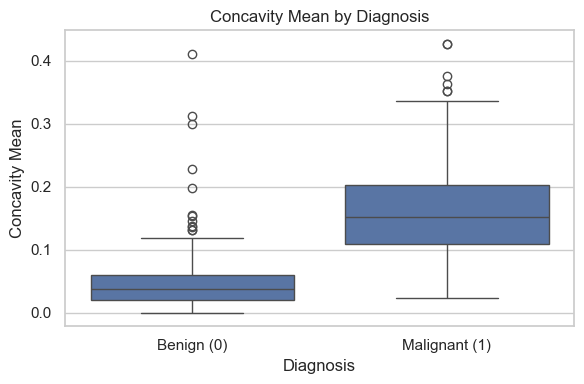

In [59]:
plt.figure()
sns.boxplot(data=df, x="Diagnosis", y="concavity_mean")
plt.xticks([0,1], ["Benign (0)", "Malignant (1)"])
plt.title("Concavity Mean by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Concavity Mean")
plt.tight_layout()
plt.savefig("/Users/kerel/Desktop/project_1_breast_cancer/figures:/fig3_concavity_boxplot.png", dpi=300)
plt.show()

In [60]:
corr = df.drop(columns=["Diagnosis"]).corr()

In [61]:
top_features = (
    df.corr()["Diagnosis"]
    .abs()
    .sort_values(ascending=False)
    .iloc[1:11]
    .index
)

top_features

Index(['concave_points_worst', 'perimeter_worst', 'concave_points_mean',
       'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean',
       'area_mean', 'concavity_mean', 'concavity_worst'],
      dtype='object')

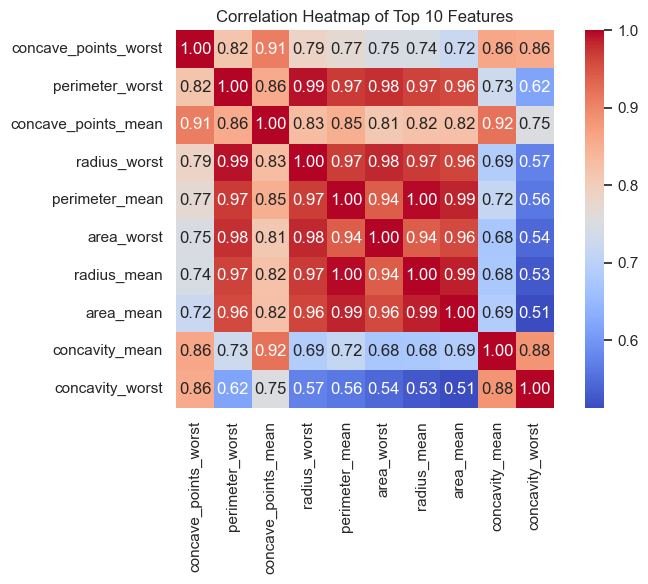

In [62]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Heatmap of Top 10 Features")
plt.tight_layout()
plt.savefig("/Users/kerel/Desktop/project_1_breast_cancer/figures:/fig4_top10_correlation_heatmap.png", dpi=300)
plt.show()

In [63]:
benign = df.loc[df["Diagnosis"] == 0, "radius_mean"]
malignant = df.loc[df["Diagnosis"] == 1, "radius_mean"]

benign.shape, malignant.shape

((357,), (212,))

In [66]:
u_stat, p_value = stats.mannwhitneyu(malignant, benign, alternative="two-sided")
u_stat, p_value

(np.float64(70955.0), np.float64(2.6929427727965647e-68))

In [67]:
def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    # Count pairwise comparisons
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x) * len(y))

delta = cliffs_delta(malignant, benign)
delta

np.float64(0.8750330320807568)

In [68]:
print(f"Mann–Whitney U test (radius_mean): U={u_stat:.0f}, p={p_value:.3e}, Cliff’s delta={delta:.3f}")

Mann–Whitney U test (radius_mean): U=70955, p=2.693e-68, Cliff’s delta=0.875


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((455, 30), (114, 30))

In [70]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [71]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

In [72]:
auc = roc_auc_score(y_test, y_prob)
auc

0.996031746031746

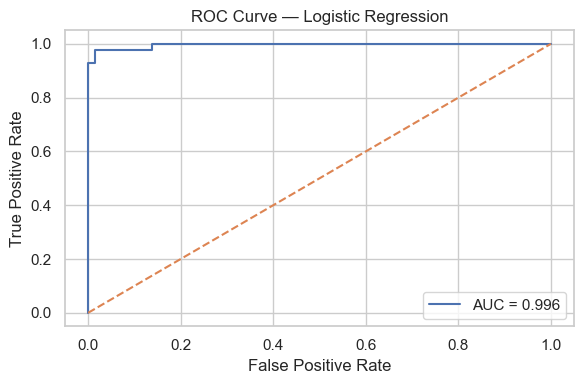

In [74]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.tight_layout()
plt.savefig("/Users/kerel/Desktop/project_1_breast_cancer/figures:/fig5_roc_curve.png", dpi=300)
plt.show()

In [75]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[71,  1],
       [ 3, 39]])

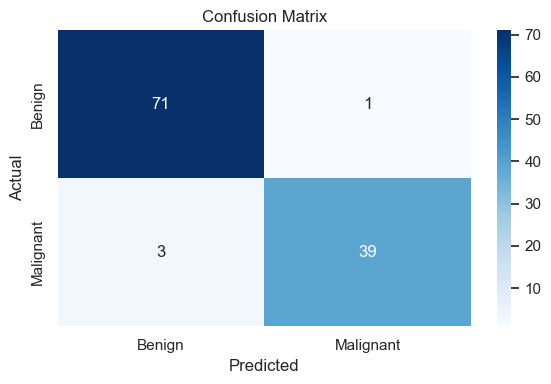

In [76]:
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("/Users/kerel/Desktop/project_1_breast_cancer/figures:/fig6_confusion_matrix.png", dpi=300)
plt.show()